<a href="https://colab.research.google.com/github/Kavishka2401/CustomerChurnPredictionSystem/blob/master/NN_baseline_model_ipynbipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mount the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Provide path
data=pd.read_csv('/content/drive/MyDrive/processed_data_NN.csv')

In [4]:
data_baselinemodel=data.copy()

In [ ]:
data_baselinemodel.head()

,customerID,tenure,MonthlyCharges,TotalCharges,Churn,TotalCharges_numeric,TotalCharges_log,gender_Male,SeniorCitizen_1,Partner_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0.013889,0.115423,29.85,0,29.85,0.072892,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,5575-GNVDE,0.472222,0.385075,1889.5,0,1889.50,0.749358,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,3668-QPYBK,0.027778,0.354229,108.15,1,108.15,0.280590,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,7795-CFOCW,0.625000,0.239303,1840.75,0,1840.75,0.745063,1,0,0,...,0,0,0,0,1,0,0,0,0,0
4,9237-HQITU,0.027778,0.521891,151.65,1,151.65,0.335724,0,0,0,...,0,0,0,0,0,0,1,0,1,0


In [6]:
# make sure the column names exist
cols_to_drop = ['Churn']

# create X by dropping columns
X = data_baselinemodel.drop(columns=cols_to_drop, axis=1)

# create y
y = data_baselinemodel['Churn']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,        # 20% test set
    stratify=y,            # preserve churn ratio
    random_state=42        # reproducible split
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape: ", X_test.shape, y_test.shape)
print("Train class counts:\n", y_train.value_counts())
print("Test class counts:\n", y_test.value_counts())

Train shape: (5634, 17) (5634,)
Test shape:  (1409, 17) (1409,)
Train class counts:
 Churn
0    4139
1    1495
Name: count, dtype: int64
Test class counts:
 Churn
0    1035
1     374
Name: count, dtype: int64


In [ ]:
X_train.info()

In [9]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [10]:
# Baseline Neural Network
baseline_model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),  # Hidden layer 1
    Dense(16, activation='relu'),                                     # Hidden layer 2
    Dense(1, activation='sigmoid')                                    # Output layer
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
from tensorflow.keras.metrics import Precision, Recall, AUC

baseline_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(), Recall(), AUC(name='auc')]
)

In [12]:
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = baseline_model.fit(
    X_train,
    y_train,
    epochs=20,             # baseline
    batch_size=32,         # default
    validation_split=0.2,  # 20% of train used as validation
    verbose=1
)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7421 - auc: 0.7584 - loss: 0.5109 - precision: 0.4349 - recall: 0.0738 - val_accuracy: 0.7835 - val_auc: 0.8066 - val_loss: 0.4563 - val_precision: 0.6509 - val_recall: 0.3729
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8015 - auc: 0.8433 - loss: 0.4173 - precision: 0.6572 - recall: 0.4895 - val_accuracy: 0.7862 - val_auc: 0.8155 - val_loss: 0.4471 - val_precision: 0.6038 - val_recall: 0.5322
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8032 - auc: 0.8466 - loss: 0.4165 - precision: 0.6493 - recall: 0.5597 - val_accuracy: 0.7817 - val_auc: 0.8184 - val_loss: 0.4466 - val_precision: 0.5825 - val_recall: 0.5864
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7940 - auc: 0.8409 - loss: 0.4201 - precision: 0.6159 - recall: 0.5732 - val_accuracy: 0.7799 - val_auc: 0.8192 - val_loss: 0.4447 - val_precision: 0.5791 - val_recall: 0.5831
Epoch 5/20
141/141 ━━━━━━━━━━━━━

177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

=== TRAIN METRICS ===
Train Accuracy: 0.8084842030528931
Train Precision: 0.662754303599374
Train Recall: 0.5665551839464883
Train F1 Score: 0.6108907320591417

=== TEST METRICS ===
Test Accuracy: 0.7970191625266146
Test Precision: 0.6375
Test Recall: 0.5454545454545454
Test F1 Score: 0.5878962536023055

=== TRAINING SET REPORT ===
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      4139
           1       0.66      0.57      0.61      1495

    accuracy                           0.81      5634
   macro avg       0.76      0.73      0.74      5634
weighted avg       0.80      0.81      0.80      5634


=== TEST SET REPORT ===
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg   

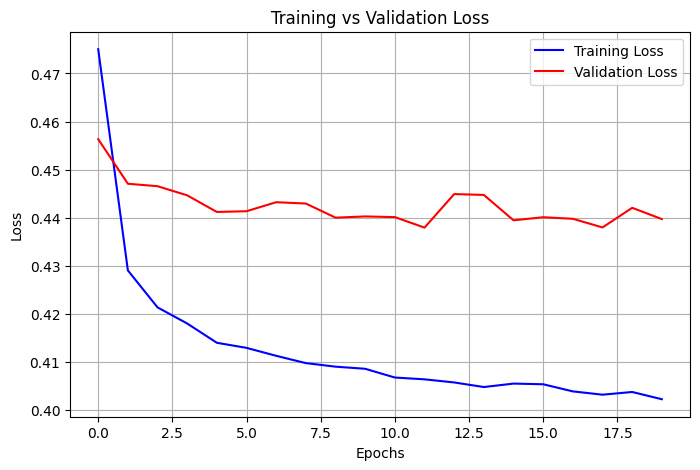

In [19]:
from sklearn.metrics import (
    f1_score, confusion_matrix, accuracy_score,
    precision_score, recall_score, classification_report
)
import matplotlib.pyplot as plt

# Predict using default threshold (0.5)
y_train_pred = (baseline_model.predict(X_train) > 0.5).astype(int)
y_test_pred  = (baseline_model.predict(X_test)  > 0.5).astype(int)

# TRAIN METRICS
print("\n=== TRAIN METRICS ===")
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Train Precision:", precision_score(y_train, y_train_pred))
print("Train Recall:", recall_score(y_train, y_train_pred))
print("Train F1 Score:", f1_score(y_train, y_train_pred))

# TEST METRICS
print("\n=== TEST METRICS ===")
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test Precision:", precision_score(y_test, y_test_pred))
print("Test Recall:", recall_score(y_test, y_test_pred))
print("Test F1 Score:", f1_score(y_test, y_test_pred))

# Classification Reports
print("\n=== TRAINING SET REPORT ===")
print(classification_report(y_train, y_train_pred))

print("\n=== TEST SET REPORT ===")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix (Test):\n", cm)

# Loss Plot
try:
    plt.figure(figsize=(8,5))
    plt.plot(history.history['loss'],     'b-', label='Training Loss')
    plt.plot(history.history['val_loss'], 'r-', label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
except:
    print("No training history available for loss plot.")


In [16]:
# Save the entire model
# Define path in your Google Drive
model_path = '/content/drive/MyDrive/NN_baseline_model.h5'

# Save the model
baseline_model.save(model_path)
print("Model saved to Google Drive at:", model_path)

# Save history
import pickle
with open('/content/drive/MyDrive/NN_baseline_model_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

Model saved to Google Drive at: /content/drive/MyDrive/NN_baseline_model.h5


Baseline Model Summary

Training Metrics

    Accuracy: 0.8085

    Precision: 0.6628

    Recall: 0.5666

    F1-score: 0.6109

Test Metrics

    Accuracy: 0.7970

    Precision: 0.6375

    Recall: 0.5455

    F1-score: 0.5879

True Negative (TN): 919

False Positive (FP): 116

False Negative (FN): 170

True Positive (TP): 204

# Feature Importance

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━

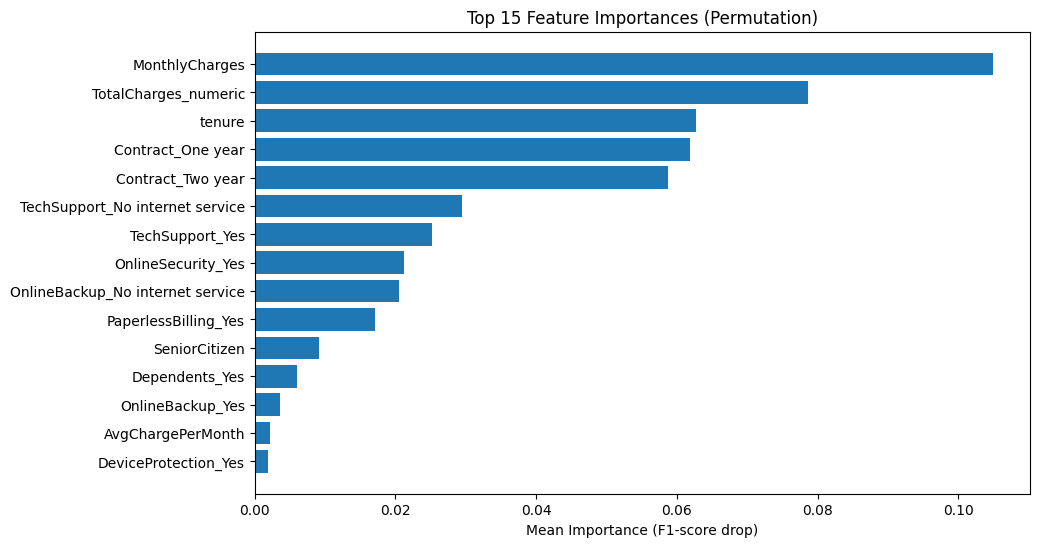

In [20]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np

# Wrap Keras model in a sklearn-like estimator
class KerasWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model):
        self.model = model

    def fit(self, X, y):
        return self  # Already trained

    def predict(self, X):
        # Convert probabilities to 0/1 labels
        y_pred_prob = self.model.predict(X)
        return (y_pred_prob > 0.5).astype(int).ravel()

# Create wrapper instance
wrapped_model = KerasWrapper(baseline_model)

# Compute permutation importance
perm_importance = permutation_importance(
    wrapped_model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1'
)

# Feature names
feature_names = X_test.columns

# Sort features by importance
sorted_idx = perm_importance.importances_mean.argsort()[::-1]

# Plot top 15 features
plt.figure(figsize=(10,6))
plt.barh(range(15), perm_importance.importances_mean[sorted_idx][:15])
plt.yticks(range(15), feature_names[sorted_idx][:15])
plt.xlabel("Mean Importance (F1-score drop)")
plt.title("Top 15 Feature Importances (Permutation)")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
import pandas as pd

# Create a DataFrame of features and their importance
feature_importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': perm_importance.importances_mean
})

# Sort by importance descending
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# Show top 10 features
top_features = feature_importance_df.head(50)
print(top_features)

                                  feature  importance
0                                  tenure    0.086903
2                        TotalCharges_log    0.080389
25                      Contract_Two year    0.076860
10            InternetService_Fiber optic    0.071861
24                      Contract_One year    0.046226
14       OnlineBackup_No internet service    0.035885
12     OnlineSecurity_No internet service    0.028160
28         PaymentMethod_Electronic check    0.023927
18        TechSupport_No internet service    0.022942
13                     OnlineSecurity_Yes    0.020665
11                     InternetService_No    0.020002
9                       MultipleLines_Yes    0.012779
6                          Dependents_Yes    0.012268
26                   PaperlessBilling_Yes    0.012085
1                          MonthlyCharges    0.011730
20        StreamingTV_No internet service    0.009449
15                       OnlineBackup_Yes    0.002907
27  PaymentMethod_Credit car

**Baseline Neural Network Model – Summary**

Model Architecture

    Input Layer: Size = number of features (X_train.shape[1])

    Hidden Layers:

      Dense(32, activation='relu')

      Dense(16, activation='relu')

      Output Layer: Dense(1, activation='sigmoid')

Training Configuration (Hyperparameters)

    Optimizer: adam (default learning rate = 0.001)

    Loss function: binary_crossentropy

    Metrics: accuracy, Precision, Recall, AUC

    Epochs: 20

    Batch size: 32

    Validation split: 20% of training data

Learned Parameters

    Weights and biases for all layers (learned during training)

Performance on Test Set

    Accuracy: 79.4%

    Precision: 64.1%

    Recall: 51.1%

    F1-score: 0.568

    AUC: 0.841

Observations


*   Accuracy is reasonably high, but recall is low.
*   Class imbalance (1:3) is likely causing the model to favor the majority class.
*   F1-score indicates the balance between precision and recall can be improved.

Next Steps

*   Address class imbalance using class weights or resampling.
*   Adjust the classification threshold to improve recall and F1-score.
*   Optionally tune hyperparameters (epochs, batch size, learning rate, dropout) after addressing imbalance.










